In [ ]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict
import gymnasium

Load trajectories

In [16]:
with open("trajectories.pickle", "rb") as f:
    trajectories = pickle.load(f)

ROWS, COLS = 31, 100

# check what is in the file:
# print(type(trajectories), len(trajectories))
# print("Example episode type:", type(trajectories[0]))
# print("Example episode length:", len(trajectories[0]))
# print("Example first step:", trajectories[0][0])

What task 5.1 is asking:

Use the recorded robot trajectories to estimate how good each state is under the unknown policy 𝜋 by averaging the total reward observed after visiting that state.

What the method returns:
The MC state-value function mc_eval_V returns a mapping from each state s to the estimated expected cumulative reward obtained when starting from s and following policy π.

Task 1:

MC evaluation for vπ(s)

In [17]:
def mc_eval_V(trajectories, gamma=1.0, first_visit=True):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    for episode in trajectories:
        # episode is a list of (s, a, r, s_next)
        states = [step[0] for step in episode]
        rewards = [float(step[2]) for step in episode]  # r_t

        # compute returns G_t backwards
        G = 0.0
        returns = [0.0] * len(rewards)
        for t in reversed(range(len(rewards))):
            G = rewards[t] + gamma * G
            returns[t] = G

        visited = set()
        for t, s in enumerate(states):
            if first_visit and s in visited:
                continue
            visited.add(s)
            returns_sum[s] += returns[t]
            returns_count[s] += 1

    V = {s: returns_sum[s] / returns_count[s] for s in returns_sum}
    return V

In [18]:
V = mc_eval_V(trajectories, gamma=1.0, first_visit=True)
print("Number of states estimated:", len(V))
print("V((15,0)):", V.get((15,0)))

Number of states estimated: 2924
V((15,0)): -78.13585565252045


Task 2:

What the question asks:

Use the same trajectories to estimate how good each state–action pair is under policy 𝜋 by averaging the total reward observed after taking action 𝑎 in state 𝑠.

What the method returns:

The MC action-value function mc_eval_Q returns a mapping from each state–action pair (s,a) to the estimated expected cumulative reward obtained when starting from s, taking action a, and then following policy π.

In [19]:
def mc_eval_Q(trajectories, gamma=1.0, first_visit=True):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    for episode in trajectories:
        states = [step[0] for step in episode]
        actions = [int(step[1]) for step in episode]
        rewards = [float(step[2]) for step in episode]

        G = 0.0
        returns = [0.0] * len(rewards)
        for t in reversed(range(len(rewards))):
            G = rewards[t] + gamma * G
            returns[t] = G

        visited = set()
        for t, (s, a) in enumerate(zip(states, actions)):
            key = (s, a)
            if first_visit and key in visited:
                continue
            visited.add(key)
            returns_sum[key] += returns[t]
            returns_count[key] += 1

    Q = {k: returns_sum[k] / returns_count[k] for k in returns_sum}
    return Q

In [20]:
Q = mc_eval_Q(trajectories, gamma=1.0, first_visit=True)
print("Number of (s,a) estimated:", len(Q))
print("Q((15,0),0):", Q.get(((15,0),0)))

Number of (s,a) estimated: 14138
Q((15,0),0): -77.43312773207876


In [37]:

# V_grid = np.zeros((ROWS, COLS))

# for (i, j), v in V.items():
#     V_grid[i, j] = v


V_grid = np.full((ROWS, COLS-1), np.nan)

for (i, j), v in V.items():
    V_grid[i, j] = v

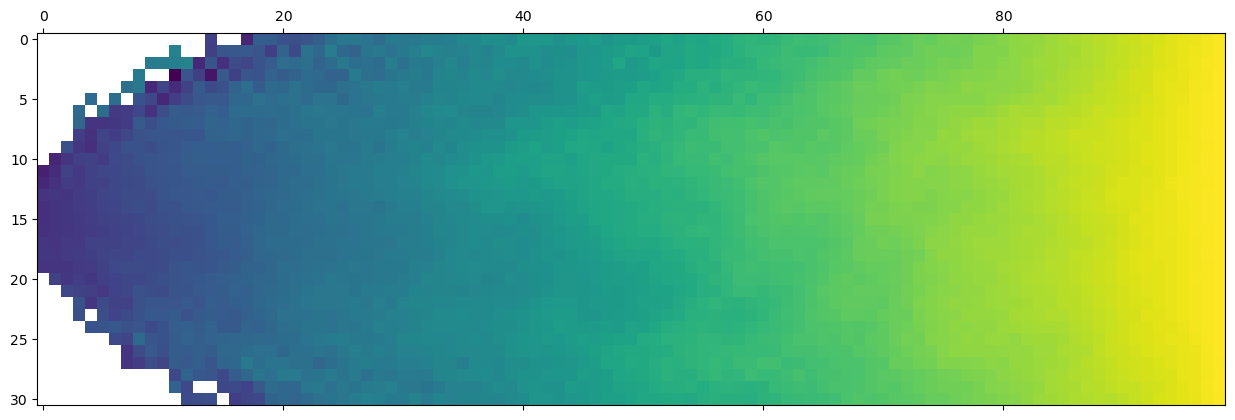

In [38]:
plt.matshow(V_grid)
# plt.figure(figsize=(12,4))
# plt.imshow(V_grid, cmap="viridis", origin="upper")
# plt.colorbar(label="vπ(s)")
# plt.title("Monte Carlo vπ(s) (only visited states)")
plt.show()

Task 4:

In [29]:
N_ACTIONS = 5  # as described in the new env

def mc_improve_policy_from_Q(Q, default_action=0):
    """
    Q: dict with keys ((i,j), a) -> q value
    returns: policy array (ROWS,COLS) with action indices
    """
    pi_new = np.full((ROWS, COLS), default_action, dtype=int)

    # group Q-values by state
    q_by_state = defaultdict(dict)
    for (s, a), q in Q.items():
        q_by_state[s][a] = q

    # choose best observed action in each visited state
    for s, qdict in q_by_state.items():
        best_a = max(qdict, key=qdict.get)
        pi_new[s] = best_a

    return pi_new

pi_new = mc_improve_policy_from_Q(Q, default_action=0)

measure how many states you actually improved:

In [30]:
visited_states = {s for (s,a) in Q.keys()}
print("States with at least one Q estimate:", len(visited_states), "out of", ROWS*COLS)

States with at least one Q estimate: 2924 out of 3100


Load mountain(v1)

Task 7:

In [ ]:
env = gymnasium.make("mountain/GridWorld-v1")